# Maximum mixed layer depth in ACCESS-OM2, calculated manually

Related issue: https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/38

Requires access to `/g/data/av17`

**Note from Katja:** This notebooks calculates the MLD manually in OM3 and OM2 from temperature and salinity, etc, so that we can correctly compare them (since as far as I know, the mld diagnostics are calculated slightly differently within OM2 vs OM3).

In [1]:
## Things remaining from MLD_manual that need to be kept

# CMOR names for the two variables we need to build MLD from scratch.
temp_standard_name = "temp"   # Conservative Temperature, Kelvin
salt_standard_name = "salt"   # Practical salinity, psu  

# Fallback variable names if the catalog doesn't expose the CMOR name directly,
temp_fallback_names = ["temp", "thetao"]
salt_fallback_names = ["salt", "so"]

# Frequency depends on the datastore you're using
data_frequency = "1mon"

# MLD calculation criterion (delta-sigma0 method)
delta_rho = 0.03      # kg/m3 density threshold
ref_depth = 10.0      # reference depth in metres

# Averaging window configuration (last N years of the run, by default)
averaging_mode = "last_n_years"   # or "full_period" / "fixed_period"
averaging_last_n_years = 10
averaging_start_date = None
averaging_end_date = None

# Path to the observational MLD product for comparison
obs_file = "/g/data/av17/access-nri/OM3/MLD-DeBoyerMontegut2023/mld_dr003_ref10m_v2023.nc"

In [2]:
import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
from pint import application_registry as ureg
import intake
import gsw
import numpy as np
import matplotlib.pyplot as plt
import cmocean as cm
import warnings
xr.set_options(keep_attrs=True);  # cf_xarray works best when xarray keeps attributes by default

# Silence the noisy-but-harmless warnings 
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
# OM2 run
exptname = '025deg_jra55_iaf_omip2_cycle1'
model_name = "ACCESS-OM2"

In [4]:
from model_agnostic import get_lon_lat_from_catalog, select_variable

In [5]:
from dask.distributed import Client
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/46145/status,
Dashboard: /proxy/46145/status,Workers: 7
Total threads: 28,Total memory: 125.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39053,Workers: 0
Dashboard: /proxy/46145/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:32895,Total threads: 4
Dashboard: /proxy/43463/status,Memory: 17.88 GiB
Nanny: tcp://127.0.0.1:37631,


### Defining MLD calculation

In [6]:
def calculate_mld_profile_om2(depth, temperature, salinity,
                               delta_rho=0.03, ref_depth=10.0,
                               lon=None, lat=None):
    """
    Compute mixed layer depth for a single water column using the
    delta-sigma0 method (Boyer Montegut et al.).

    Parameters
    ----------
    temperature : Potential Temperature in Kelvin
    salinity    : Practical Salinity in PSU
    depth       : in metres, positive downward
    """
    # Drop any level where T, S, or depth is missing (land / below bathymetry)
    valid = np.isfinite(temperature) & np.isfinite(salinity) & np.isfinite(depth)
    if valid.sum() < 2:
        return np.nan

    depth       = depth[valid].astype(float)
    temperature = temperature[valid].astype(float)
    salinity    = salinity[valid].astype(float)

    # Make sure the profile is depth-sorted (should already be, but cheap to guarantee)
    sort_idx    = np.argsort(depth)
    depth       = depth[sort_idx]
    temperature = temperature[sort_idx]
    salinity    = salinity[sort_idx]

    # If the whole profile is shallower than the reference depth, MLD is undefined here
    if depth[-1] <= ref_depth:
        return np.nan

    if lon is None or lat is None:
        raise ValueError("lon and lat must be provided")

    # Convert to TEOS-10 variables required by gsw for a physically consistent density
    SA = gsw.SA_from_SP(salinity, depth, lon=float(lon), lat=float(lat))
    CT = temperature - 273.15 # Converting from Kelvin
    sigma0 = gsw.sigma0(SA, CT)

    if ref_depth < depth[0]:
        return np.nan
    # Reference density interpolated to exactly ref_depth
    rho_ref = np.interp(ref_depth, depth, sigma0)

    # Only look below the reference depth for where density first exceeds the threshold
    below   = depth > ref_depth
    if below.sum() == 0:
        return np.nan

    d_s     = depth[below]
    sig_s   = sigma0[below]
    exceeds = np.where(np.abs(sig_s - rho_ref) > delta_rho)[0]

    if len(exceeds) == 0:
        return np.nan

    idx = exceeds[0]
    if idx == 0:
        return float(d_s[0])

    # Linearly interpolate between the last level below threshold and the first level
    # above it, so the MLD estimate isn't just snapped to the model's discrete levels
    d0, d1 = d_s[idx - 1], d_s[idx]
    s0, s1 = sig_s[idx - 1], sig_s[idx]
    denom  = abs(s1 - rho_ref) - abs(s0 - rho_ref)
    frac   = 0.0 if denom == 0 else (delta_rho - abs(s0 - rho_ref)) / denom
    return float(d0 + frac * (d1 - d0))

In [7]:
def calculate_mld_model(temperature, salinity,
                         delta_rho=0.03, ref_depth=10.0,
                         depth_dim="st_ocean", time_sel=None):
    """
    Vectorised wrapper around calculate_mld_profile_om2: applies the
    per-column calculation across every (time, y, x) point using
    xr.apply_ufunc + dask, so it stays lazy until .compute() is called.
    """
    if time_sel is not None:
        temperature = temperature.sel(time=time_sel)
        salinity    = salinity.sel(time=time_sel)

    # The vertical dimension can't be chunked for apply_ufunc to see a full profile
    temp_ch    = temperature.chunk({depth_dim: -1})
    salt_ch    = salinity.chunk({depth_dim: -1})
    depth_vals = temp_ch[depth_dim].values.astype(float)

    def _mld_1d(temp_col, salt_col, lon_val, lat_val):
        return calculate_mld_profile_om2(depth_vals, temp_col, salt_col,
                                          delta_rho=delta_rho, ref_depth=ref_depth,
                                          lon=lon_val, lat=lat_val)

    mld = xr.apply_ufunc(
        _mld_1d, temp_ch, salt_ch,
        salt_ch["xt_ocean"],   # check your model coordinate name
        salt_ch["yt_ocean"],
        input_core_dims=[[depth_dim], [depth_dim], [], []],
        output_dtypes=[float],
        vectorize=True,
        dask="parallelized",
    )

    mld.name = "mld"
    mld.attrs["units"] = "m"
    mld.attrs["long_name"] = "Mixed Layer Depth"
    mld.attrs["criterion"] = f"delta_sigma0 > {delta_rho} kg/m3 from {ref_depth} m"
    return mld

### Load model temperature and salinity from the datastore

In [8]:
# Open the experiment's ESM datastore
datastore = intake.cat.access_nri[exptname]

temp_model = select_variable(
    datastore,
    temp_standard_name,
    temp_fallback_names,
    data_frequency=data_frequency,
)
salt_model = select_variable(
    datastore,
    salt_standard_name,
    salt_fallback_names,
    data_frequency=data_frequency,
)

print("Selected temperature variable:", temp_model.name, "dims:", temp_model.dims)
print("Selected salinity variable:", salt_model.name, "dims:", salt_model.dims)

CF-based lookup failed: ValueError('No entries found for this CF standard_name.')
Selected variable via fallback name: temp
CF-based lookup failed: ValueError('No entries found for this CF standard_name.')
Selected variable via fallback name: salt
Selected temperature variable: temp dims: ('time', 'st_ocean', 'yt_ocean', 'xt_ocean')
Selected salinity variable: salt dims: ('time', 'st_ocean', 'yt_ocean', 'xt_ocean')


In [9]:
# Discover lon/lat from the catalog's grid variables (same helper as MLD.ipynb)
lon, lat = get_lon_lat_from_catalog(datastore)

# Ensure the temperature field has CF-recognisable longitude/latitude coords
try:
    _ = temp_model.cf["longitude"]
    _ = temp_model.cf["latitude"]
    print("Using existing CF longitude/latitude on temp_model.")
except KeyError:
    temp_model = temp_model.cf.assign_coords({"longitude": lon, "latitude": lat})
    salt_model = salt_model.cf.assign_coords({"longitude": lon, "latitude": lat})
    print("Attached longitude/latitude from catalog grid variables.")

Using existing CF longitude/latitude on temp_model.


### Compute MLD from temperature and salinity

In [10]:
# Compute MLD across the full time series (still lazy — nothing computed yet)
mld_model = calculate_mld_model(
    temp_model,
    salt_model,
    delta_rho=delta_rho,
    ref_depth=ref_depth,
    depth_dim="st_ocean",
)
mld_model

<xarray.DataArray 'mld' (time: 732, yt_ocean: 1080, xt_ocean: 1440)> Size: 9GB
dask.array<transpose, shape=(732, 1080, 1440), dtype=float64, chunksize=(12, 108, 120), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) object 6kB 1958-01-14 12:00:00 ... 2018-12-14 12:00:00
  * yt_ocean  (yt_ocean) float64 9kB -81.08 -80.97 -80.87 ... 89.74 89.84 89.95
  * xt_ocean  (xt_ocean) float64 12kB -279.9 -279.6 -279.4 ... 79.38 79.62 79.88
Attributes:
    long_name:      Mixed Layer Depth
    units:          m
    valid_range:    [-10. 500.]
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    standard_name:  sea_water_conservative_temperature
    criterion:      delta_sigma0 > 0.03 kg/m3 from 10.0 m

### Configure the averaging window

In [11]:
# Put model time axis on a common calendar
mld_model = mld_model.convert_calendar("proleptic_gregorian", use_cftime=True)

# Inspect full time coverage
t0 = mld_model.time.values[0]
t1 = mld_model.time.values[-1]
print("Full model time range:", t0, "→", t1)

# Decide the averaging window based on configuration 
import cftime

if averaging_mode == "full_period":
    datestart = t0
    datestop = t1
elif averaging_mode == "last_n_years":
    datestop = t1
    datelist = list(cftime.to_tuple(datestop))
    datelist[0] -= averaging_last_n_years
    datestart = cftime.datetime(*datelist, calendar=datestop.calendar)
elif averaging_mode == "fixed_period":
    if averaging_start_date is None or averaging_end_date is None:
        raise ValueError(
            "averaging_mode='fixed_period' requires averaging_start_date and averaging_end_date"
        )
    datestart = xr.cftime_range(start=averaging_start_date, periods=1,
                                 calendar="proleptic_gregorian")[0]
    datestop = xr.cftime_range(start=averaging_end_date, periods=1,
                                calendar="proleptic_gregorian")[0]
else:
    raise ValueError(f"Unknown averaging_mode: {averaging_mode!r}")

timerange = slice(datestart, datestop)
print("Averaging window:", timerange)

mld_model_window = mld_model.cf.sel(time=timerange)
print("Windowed dims:", mld_model_window.dims)

Full model time range: 1958-01-14 12:00:00 → 2018-12-14 12:00:00
Averaging window: slice(cftime.datetime(2008, 12, 14, 12, 0, 0, 0, calendar='proleptic_gregorian', has_year_zero=True), cftime.DatetimeProlepticGregorian(2018, 12, 14, 12, 0, 0, 0, has_year_zero=True), None)
Windowed dims: ('time', 'yt_ocean', 'xt_ocean')


In [12]:
# Load and prepare the observational product the same way
obs_mld = xr.open_dataset(obs_file)["mld_dr003"]
obs_mld.attrs["units"] = obs_mld.attrs.get("unit", obs_mld.attrs.get("units"))

## Defining spatial plot

In [13]:
# Blue Marble background image, so that land is rendered underneath the ocean-only MLD field (MLD has no values over land)
blue_marble = plt.imread('/g/data/ik11/grids/BlueMarble.tiff')
blue_marble_extent = (-180, 180, -90, 90)

def plot(dat, title=None, ax=None, **kwargs):
    """
    Plot a single 2D lon/lat field on a Robinson projection with a Blue Marble
    land background underneath, matching the style used throughout MLD.ipynb.

    If `ax` is not supplied, a new figure+axes is created (single-panel case).
    If `ax` is supplied, it must already be a GeoAxes with a Robinson projection
    (this is what lets us reuse this function for the side-by-side panels below).
    """
    if title is None:
        title = dat.attrs.get('long_name', dat.name)

    created_fig = False
    if ax is None:
        fig = plt.figure(figsize=(12, 6))
        ax = plt.axes(projection=ccrs.Robinson(central_longitude=-100))
        created_fig = True

    # contourf the MLD field itself, transforming from plain lon/lat into the
    # Robinson projection on the fly
    cf = dat.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cbar_kwargs={"label": "\n".join(wrap(f"{dat.attrs.get('long_name', dat.name)} [{dat.attrs.get('units', '')}]", 45)),
                     "fraction": 0.03, "aspect": 15, "shrink": 0.7},
        **kwargs
    )

    # Add blue marble land on top, so land shows through where MLD is NaN
    ax.imshow(
        blue_marble, extent=blue_marble_extent, transform=ccrs.PlateCarree(), origin="upper"
    )

    ax.set_title(title)
    return cf

In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cft
from textwrap import wrap

### Seasonal averaging

In [15]:
def seasonal_mean(da, months):
    """
    Time-weighted mean over the timesteps whose month falls in `months`
    (e.g. [1, 2, 3] for JFM). Weighting by days-in-month accounts for the
    fact that monthly means aren't all equally long.
    """
    da_m = da.where(da["time"].dt.month.isin(months), drop=True)
    w_m  = w.where(da["time"].dt.month.isin(months), drop=True)
    return da_m.weighted(w_m).mean("time")

In [16]:
# Weights = days in each timestep's month, computed over the same averaging
# window (mld_model_window) established earlier via `timerange`
w = mld_model_window["time"].dt.days_in_month

# Compute JFM and JAS area-weighted-in-time seasonal means for the model MLD.
# Note: this is a *temporal* seasonal mean at each grid point (still 2D in
# space), as distinct from mld_model_mean, which was a *spatial* mean at each
# timestep (still 1D in time). They answer different questions:
#   - mld_model_mean:      "how does area-averaged MLD vary over the decade?"
#   - model_JFM_mean/JAS:  "what does the MLD map look like in summer/winter, averaged over the decade?"
model_JFM_mean = seasonal_mean(mld_model_window, [1, 2, 3])
model_JAS_mean = seasonal_mean(mld_model_window, [7, 8, 9])

**Note:** The `.compute()` below takes a little while to load. For testing purposes, I have saved copies for OM2 cycle1 under:
  
`model_JFM_mean = xr.open_dataarray('/g/data/g40/kc5856/random/om2_c1_JFM_calc_MLD_mean.nc')`  
`model_JAS_mean = xr.open_dataarray('/g/data/g40/kc5856/random/om2_c1_JAS_calc_MLD_mean.nc')`

In [19]:
model_JFM_mean = model_JFM_mean.compute()

2026-08-31 12:14:27,960 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:32895 -> tcp://127.0.0.1:46863
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
                 ^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/tornado/iostream.py", line 1113, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TimeoutError: [Errno 110] Connection timed out

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/worker.py", line 1803, in get_data
    response = await comm.read(deserializers=serializers)
               ^^^^^^^

In [21]:
model_JAS_mean = model_JAS_mean.compute()

2026-08-31 12:20:25,572 - distributed.worker - ERROR - failed during get data with tcp://127.0.0.1:32895 -> tcp://127.0.0.1:44795
Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/tornado/iostream.py", line 861, in _read_to_buffer
    bytes_read = self.read_from_fd(buf)
                 ^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/tornado/iostream.py", line 1113, in read_from_fd
    return self.socket.recv_into(buf, len(buf))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TimeoutError: [Errno 110] Connection timed out

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/distributed/worker.py", line 1803, in get_data
    response = await comm.read(deserializers=serializers)
               ^^^^^^^

## Plotting

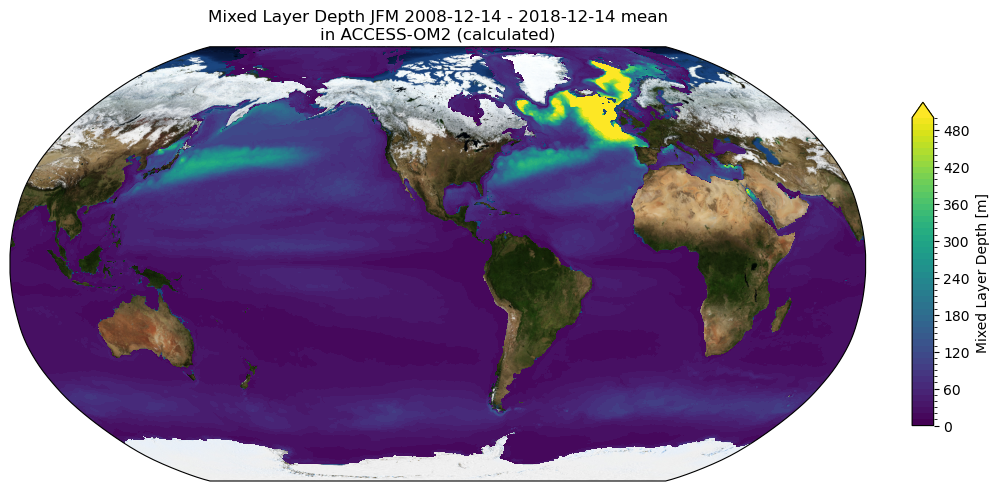

In [23]:
plot(model_JFM_mean,
    levels=51,
    vmin=0,
    vmax=500,
    extend="max",
    cmap='viridis',
    title=f"{mld_model_window.attrs['long_name']} JFM "
          f"{mld_model_window.time.values[0].strftime('%Y-%m-%d')} - "
          f"{mld_model_window.time.values[-1].strftime('%Y-%m-%d')} mean\nin {model_name} (calculated)"
    )
# mkmd.savefig(plt.gcf(), "Mixed Layer Depth: OM2 JFM (manual calc)",
#              "Ocean Mixed Layer Depth JFM, calculated manually from temperature and salinity. "
#              "GitHub issue: [#38](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/38)")

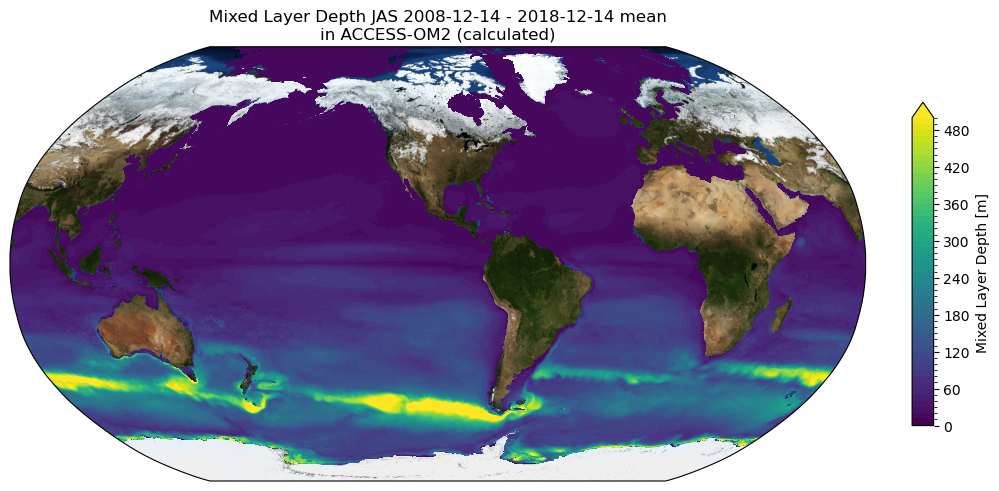

In [24]:
plot(model_JAS_mean,
    levels=51,
    vmin=0,
    vmax=500,
    extend="max",
    cmap='viridis',
    title=f"{mld_model_window.attrs['long_name']} JAS "
          f"{mld_model_window.time.values[0].strftime('%Y-%m-%d')} - "
          f"{mld_model_window.time.values[-1].strftime('%Y-%m-%d')} mean\nin {model_name} (calculated)"
     )
# mkmd.savefig(plt.gcf(), "Mixed Layer Depth: OM2 JAS (manual calc)",
#              "Ocean Mixed Layer Depth JAS, calculated manually from temperature and salinity. "
#              "GitHub issue: [#38](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/38)")

In [25]:
# TODO: append copy of westernmost data to eastern end to avoid gap in plot
# (same caveat noted in MLD.ipynb — DeBoyerMontegut obs has a longitude seam)

# DeBoyerMontegut is a 12-month climatology, so JFM/JAS means are a simple
# unweighted mean over the relevant 3 climatological months, not a
# days-in-month-weighted mean over many years like the model side above
obs_JFM_mean = obs_mld.isel(time=[0, 1, 2]).mean('time').load()
obs_JAS_mean = obs_mld.isel(time=[6, 7, 8]).mean('time').load()

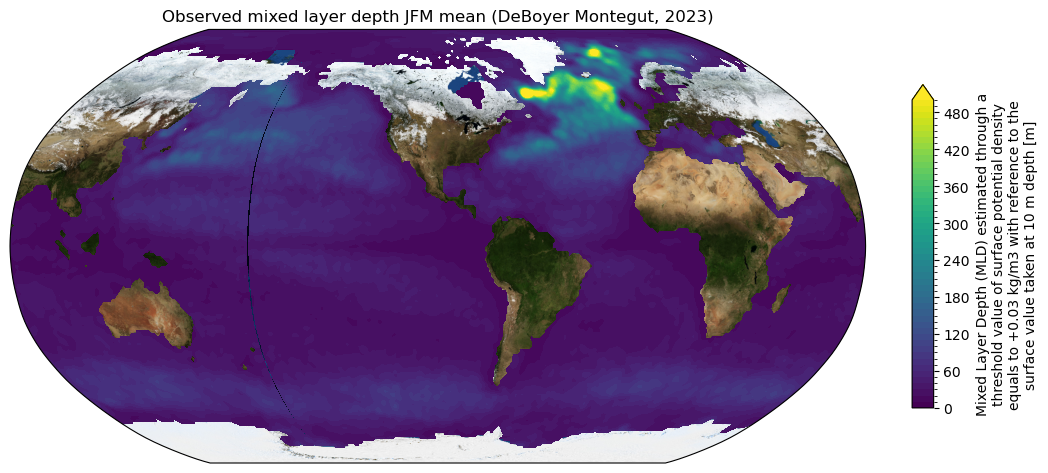

In [26]:
plot(obs_JFM_mean,
    levels=51,
    vmin=0,
    vmax=500,
    extend="max",
    cmap='viridis',
    title="Observed mixed layer depth JFM mean (DeBoyer Montegut, 2023)"
    )
# mkmd.savefig(plt.gcf(), "Mixed Layer Depth: Observed JFM", # Don't need to save this because it should already be done in MLD.ipynb
#              "Observed ocean Mixed Layer Depth JFM. GitHub issue: "
#              "[#38](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/38)")

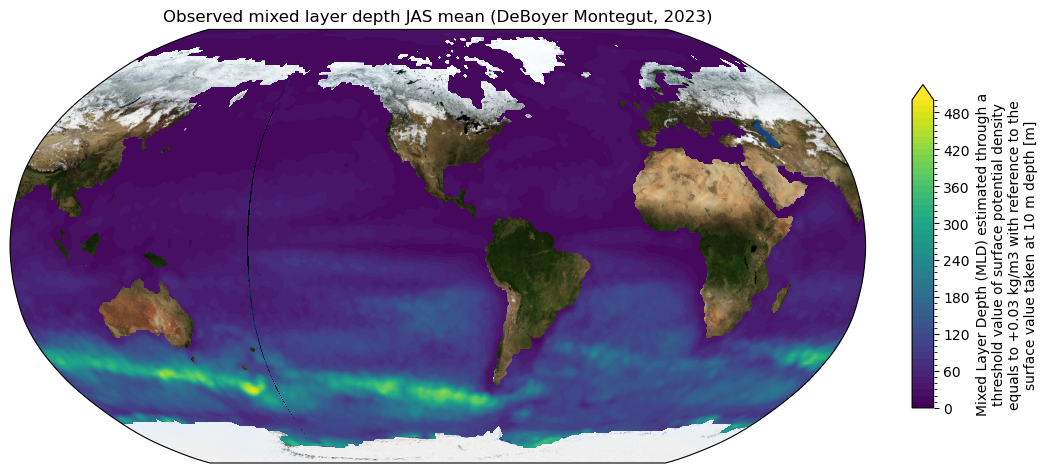

In [27]:
plot(obs_JAS_mean,
    levels=51,
    vmin=0,
    vmax=500,
    extend="max",
    cmap='viridis',
    title="Observed mixed layer depth JAS mean (DeBoyer Montegut, 2023)"
    )
# mkmd.savefig(plt.gcf(), "Mixed Layer Depth: Observed JAS", # Don't need to save this because it should already be done in MLD.ipynb
#              "Observed ocean Mixed Layer Depth JAS. GitHub issue: "
#              "[#38](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/38)")

### Side-by-side comparison: model vs observations

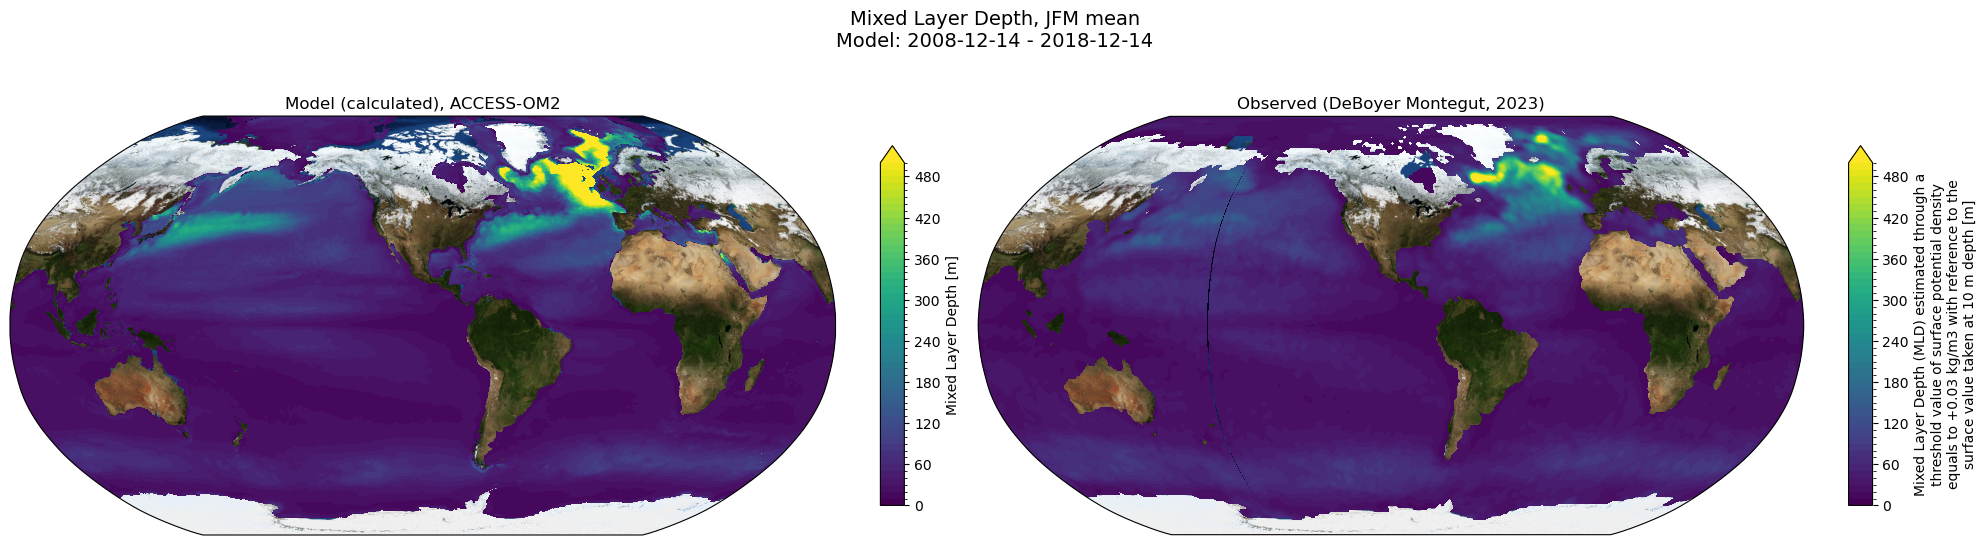

In [28]:
# Two-panel figure: model (left) and obs (right), sharing a Robinson projection
# and the same colour scale/levels, so the maps are directly comparable by eye
fig, (ax_model, ax_obs) = plt.subplots(
    1, 2, figsize=(20, 6),
    subplot_kw={"projection": ccrs.Robinson(central_longitude=-100)}
)

plot(model_JFM_mean,
     ax=ax_model,
     levels=51, vmin=0, vmax=500, extend="max", cmap='viridis',
     title=f"Model (calculated), {model_name}")

plot(obs_JFM_mean,
     ax=ax_obs,
     levels=51, vmin=0, vmax=500, extend="max", cmap='viridis',
     title="Observed (DeBoyer Montegut, 2023)")

fig.suptitle(
    f"Mixed Layer Depth, JFM mean\n"
    f"Model: {mld_model_window.time.values[0].strftime('%Y-%m-%d')} - "
    f"{mld_model_window.time.values[-1].strftime('%Y-%m-%d')}",
    fontsize=14
)
plt.tight_layout()

# mkmd.savefig(fig, "Mixed Layer Depth: Model vs Observed JFM (side by side)",
#              "Side-by-side comparison of calculated model MLD and DeBoyer Montegut (2023) "
#              "observed MLD, JFM mean. GitHub issue: "
#              "[#38](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/38)")

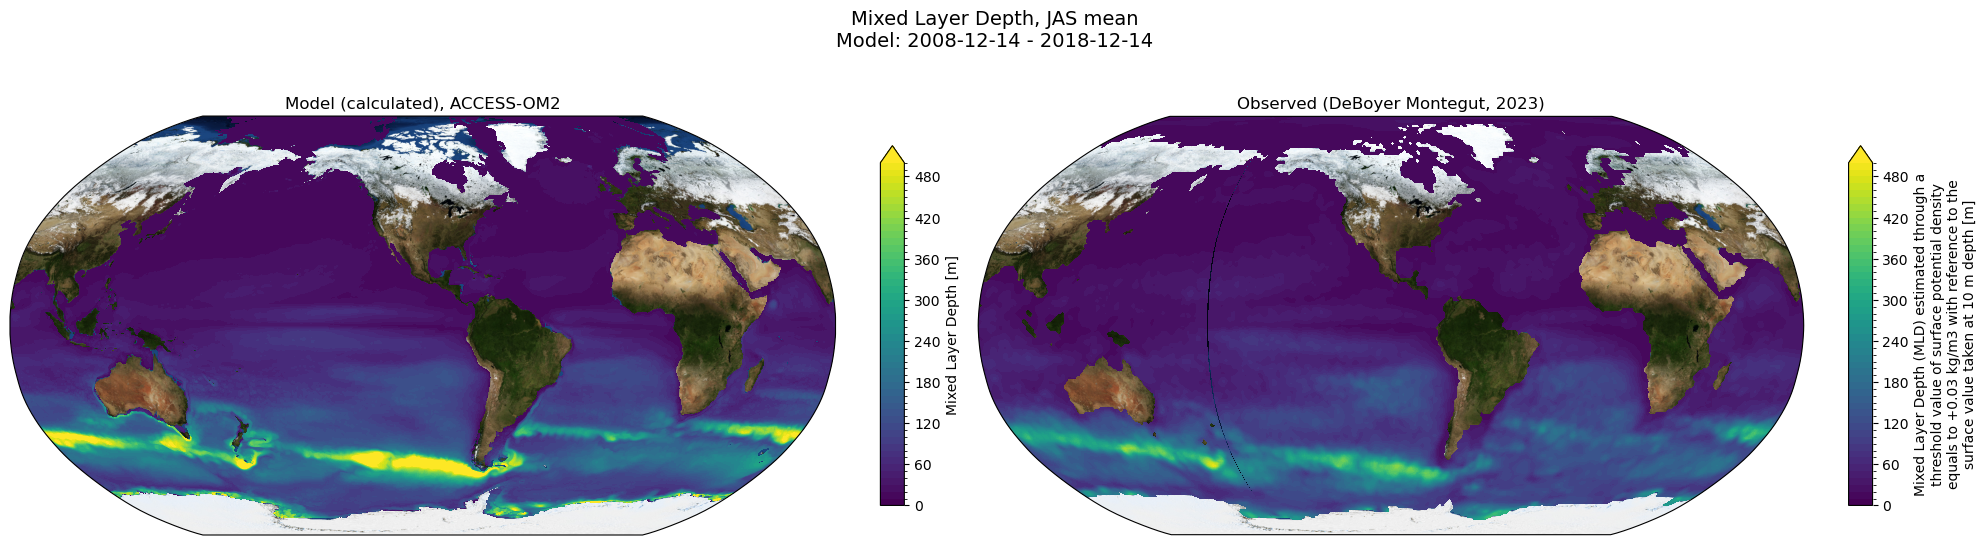

In [29]:
fig, (ax_model, ax_obs) = plt.subplots(
    1, 2, figsize=(20, 6),
    subplot_kw={"projection": ccrs.Robinson(central_longitude=-100)}
)

plot(model_JAS_mean,
     ax=ax_model,
     levels=51, vmin=0, vmax=500, extend="max", cmap='viridis',
     title=f"Model (calculated), {model_name}")

plot(obs_JAS_mean,
     ax=ax_obs,
     levels=51, vmin=0, vmax=500, extend="max", cmap='viridis',
     title="Observed (DeBoyer Montegut, 2023)")

fig.suptitle(
    f"Mixed Layer Depth, JAS mean\n"
    f"Model: {mld_model_window.time.values[0].strftime('%Y-%m-%d')} - "
    f"{mld_model_window.time.values[-1].strftime('%Y-%m-%d')}",
    fontsize=14
)
plt.tight_layout()

# mkmd.savefig(fig, "Mixed Layer Depth: Model vs Observed JAS (side by side)",
#              "Side-by-side comparison of calculated model MLD and DeBoyer Montegut (2023) "
#              "observed MLD, JAS mean. GitHub issue: "
#              "[#38](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/38)")

# Anomaly between Obs and OM3

In [30]:
from scipy.interpolate import interp1d
import cartopy.feature as cfeature

In [31]:
# Creating new spatial plot to look nice with anomalies
def plot_anomaly(dat, title=None, ax=None, **kwargs):
    """
    Plot a single 2D lon/lat field on a Robinson projection with land shown
    as light grey with a black coastline, matching the style used throughout
    MLD.ipynb.
    If `ax` is not supplied, a new figure+axes is created (single-panel case).
    If `ax` is supplied, it must already be a GeoAxes with a Robinson projection
    (this is what lets us reuse this function for the side-by-side panels below).
    """
    if title is None:
        title = dat.attrs.get('long_name', dat.name)
    created_fig = False
    if ax is None:
        fig = plt.figure(figsize=(12, 6))
        ax = plt.axes(projection=ccrs.Robinson(central_longitude=-100))
        created_fig = True
    # contourf the MLD field itself, transforming from plain lon/lat into the
    # Robinson projection on the fly
    cf = dat.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cbar_kwargs={"label": "\n".join(wrap(f"{dat.attrs.get('long_name', dat.name)} [{dat.attrs.get('units', '')}]", 45)),
                     "fraction": 0.03, "aspect": 15, "shrink": 0.7},
        **kwargs
    )
    # Add light grey land fill with a black coastline on top, so land shows
    # through where MLD is NaN
    ax.add_feature(cfeature.LAND, zorder=1, facecolor="lightgrey")
    ax.add_feature(cfeature.COASTLINE, zorder=2, edgecolor="black", linewidth=0.8)
    ax.set_title(title)
    return cf

In [32]:
# Renaming coordinates to match obs
model_JFM_mean_new = model_JFM_mean.rename({'xt_ocean': 'lon', 'yt_ocean': 'lat'})
model_JAS_mean_new = model_JAS_mean.rename({'xt_ocean': 'lon', 'yt_ocean': 'lat'})

# Convert model longitude to [-180, 180]
model_JFM_mean_new = model_JFM_mean_new.assign_coords(lon=((model_JFM_mean_new.lon + 180) % 360) - 180)
model_JAS_mean_new = model_JAS_mean_new.assign_coords(lon=((model_JAS_mean_new.lon + 180) % 360) - 180)

# Sort after wrapping (important for interp)
model_JFM_mean_new = model_JFM_mean_new.sortby('lon')
model_JAS_mean_new = model_JAS_mean_new.sortby('lon')

# Interpolate
model_JFM_mean_interp = model_JFM_mean_new.interp(lat=obs_JFM_mean.lat, lon=obs_JFM_mean.lon)
model_JAS_mean_interp = model_JAS_mean_new.interp(lat=obs_JAS_mean.lat, lon=obs_JAS_mean.lon)

In [33]:
anomaly_JFM = model_JFM_mean_interp - obs_JFM_mean
anomaly_JAS = model_JAS_mean_interp - obs_JAS_mean

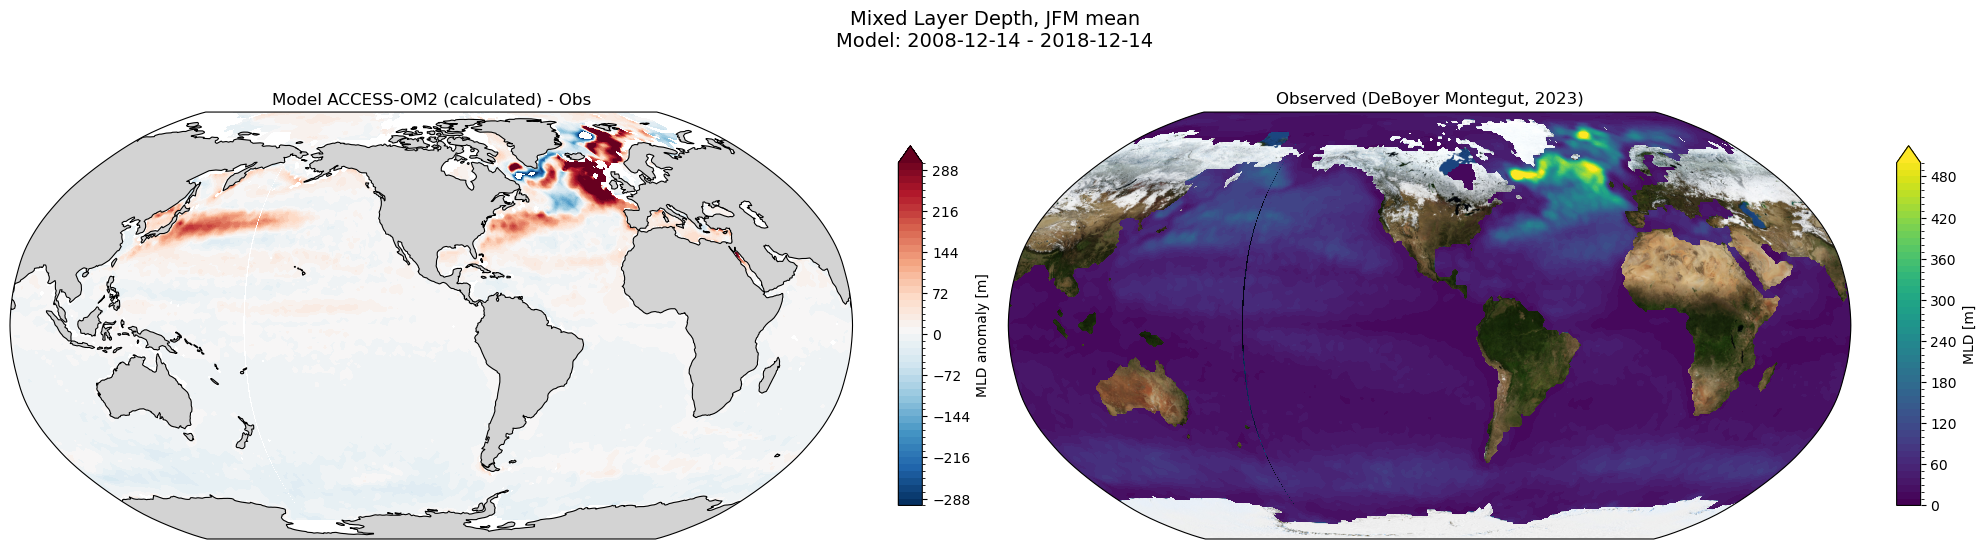

In [34]:
# Two-panel figure: model (left) and obs (right), sharing a Robinson projection
# and the same colour scale/levels, so the maps are directly comparable by eye
fig, (ax_model, ax_obs) = plt.subplots(
    1, 2, figsize=(20, 6),
    subplot_kw={"projection": ccrs.Robinson(central_longitude=-100)}
)

cf_model = plot_anomaly(anomaly_JFM,
     ax=ax_model,
     levels=51, vmin=-300, vmax=300, extend="max", cmap='RdBu_r',
     title=f"Model {model_name} (calculated) - Obs")
cf_model.colorbar.set_label("MLD anomaly [m]")

cf_obs = plot(obs_JFM_mean,
     ax=ax_obs,
     levels=51, vmin=0, vmax=500, extend="max", cmap='viridis',
     title="Observed (DeBoyer Montegut, 2023)")
cf_obs.colorbar.set_label("MLD [m]")

fig.suptitle(
    f"Mixed Layer Depth, JFM mean\n"
    f"Model: {mld_model_window.time.values[0].strftime('%Y-%m-%d')} - "
    f"{mld_model_window.time.values[-1].strftime('%Y-%m-%d')}",
    fontsize=14
)
plt.tight_layout()

# mkmd.savefig(fig, "Mixed Layer Depth: OM2 Anomaly vs Observed JFM (side by side)",
#              "Side-by-side comparison of calculated OM2 MLD anomaly and DeBoyer Montegut (2023) "
#              "observed MLD, JFM mean. GitHub issue: "
#              "[#38](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/38)")

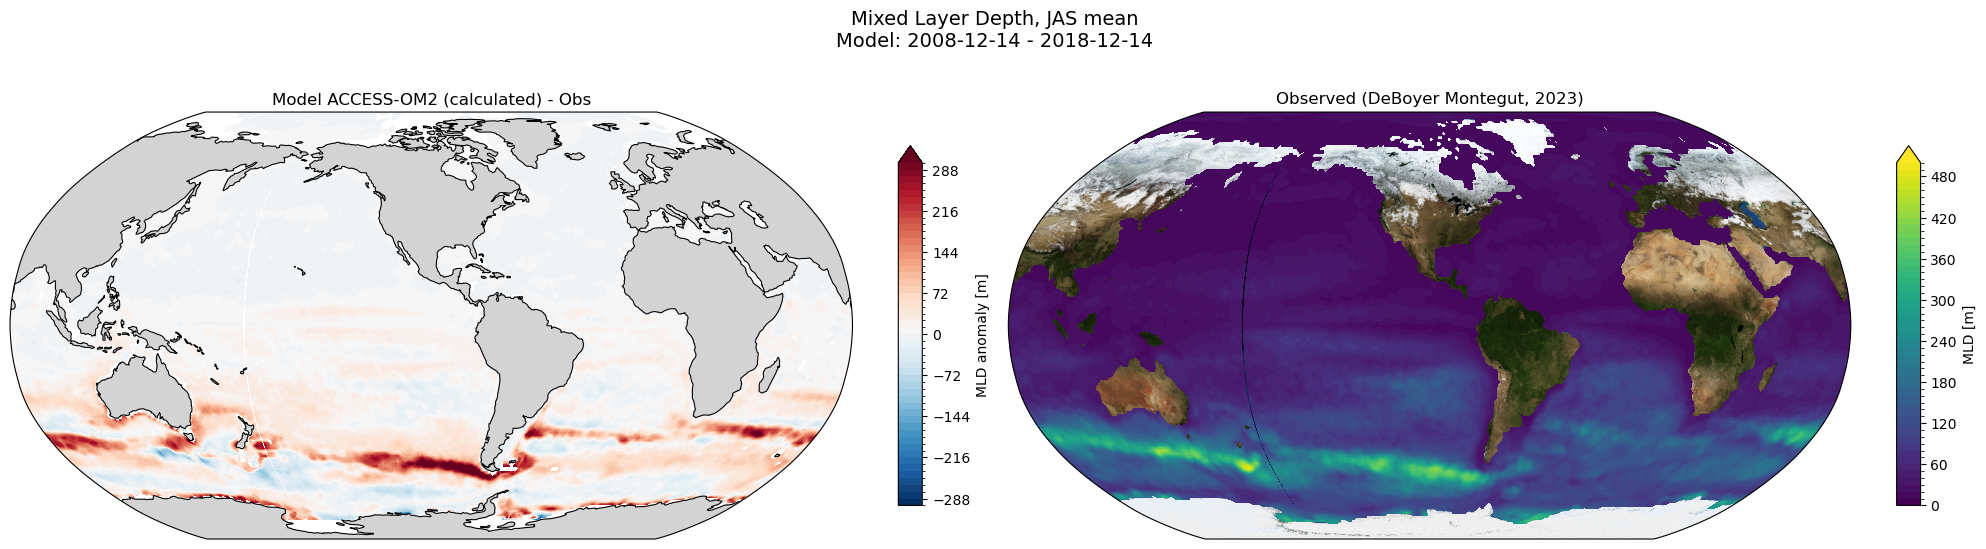

In [35]:
# Two-panel figure: model (left) and obs (right), sharing a Robinson projection
# and the same colour scale/levels, so the maps are directly comparable by eye
fig, (ax_model, ax_obs) = plt.subplots(
    1, 2, figsize=(20, 6),
    subplot_kw={"projection": ccrs.Robinson(central_longitude=-100)}
)

cf_model = plot_anomaly(anomaly_JAS,
     ax=ax_model,
     levels=51, vmin=-300, vmax=300, extend="max", cmap='RdBu_r',
     title=f"Model {model_name} (calculated) - Obs")
cf_model.colorbar.set_label("MLD anomaly [m]")

cf_obs = plot(obs_JAS_mean,
     ax=ax_obs,
     levels=51, vmin=0, vmax=500, extend="max", cmap='viridis',
     title="Observed (DeBoyer Montegut, 2023)")
cf_obs.colorbar.set_label("MLD [m]")

fig.suptitle(
    f"Mixed Layer Depth, JAS mean\n"
    f"Model: {mld_model_window.time.values[0].strftime('%Y-%m-%d')} - "
    f"{mld_model_window.time.values[-1].strftime('%Y-%m-%d')}",
    fontsize=14
)
plt.tight_layout()

# mkmd.savefig(fig, "Mixed Layer Depth: OM2 Anomaly vs Observed JAS (side by side)",
#              "Side-by-side comparison of calculated OM2 MLD anomaly and DeBoyer Montegut (2023) "
#              "observed MLD, JAS mean. GitHub issue: "
#              "[#38](https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/38)")